In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, timedelta
import sys
print(sys.executable)

C:\Users\ethan\Projects\mlops-weather-forecast\.venv\Scripts\python.exe


In [7]:
# Pull a full year of daily weather data — Cape Town
# Open-Meteo's Historical Weather API is completely free, no API key needed
# Note: ERA5 data has a ~7 day processing delay, so end_date can't be today
end_date = date.today() - timedelta(days=7)
start_date = end_date - timedelta(days=365)

response = requests.get("https://archive-api.open-meteo.com/v1/archive", params={
    "latitude": -33.92,
    "longitude": 18.42,
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "precipitation_sum",
        "wind_speed_10m_max",
        "shortwave_radiation_sum",
    ],
    "start_date": start_date.isoformat(),
    "end_date": end_date.isoformat(),
    "timezone": "Africa/Johannesburg",
})
response.raise_for_status()   # throws an error if the API call failed

In [10]:
df = pd.DataFrame(response.json()["daily"])
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

In [12]:
print(f"Shape: {df.shape}")
print(f"Date range: {df['time'].min()} → {df['time'].max()}")
df.head()

Shape: (366, 6)
Date range: 2025-06-29 00:00:00 → 2026-06-29 00:00:00


,time,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum
0,2025-06-29,17.7,12.3,4.4,12.1,6.16
1,2025-06-30,16.7,7.6,0.1,15.9,10.56
2,2025-07-01,15.2,10.3,1.6,19.0,5.66
3,2025-07-02,15.9,12.3,6.7,16.0,3.72
4,2025-07-03,14.6,11.9,29.3,17.4,2.43


=== Missing Values ===
time                       0
temperature_2m_max         0
temperature_2m_min         0
precipitation_sum          0
wind_speed_10m_max         0
shortwave_radiation_sum    0
dtype: int64

=== Basic Statistics ===
                                time  temperature_2m_max  temperature_2m_min  \
count                            366           366.00000          366.000000   
mean   2025-12-28 11:59:59.999999744            21.95765           13.955191   
min              2025-06-29 00:00:00            13.50000            6.200000   
25%              2025-09-28 06:00:00            17.50000           11.425000   
50%              2025-12-28 12:00:00            21.55000           13.800000   
75%              2026-03-29 18:00:00            25.57500           16.800000   
max              2026-06-29 00:00:00            41.10000           27.000000   
std                              NaN             5.44819            3.473581   

       precipitation_sum  wind_speed_10m_ma

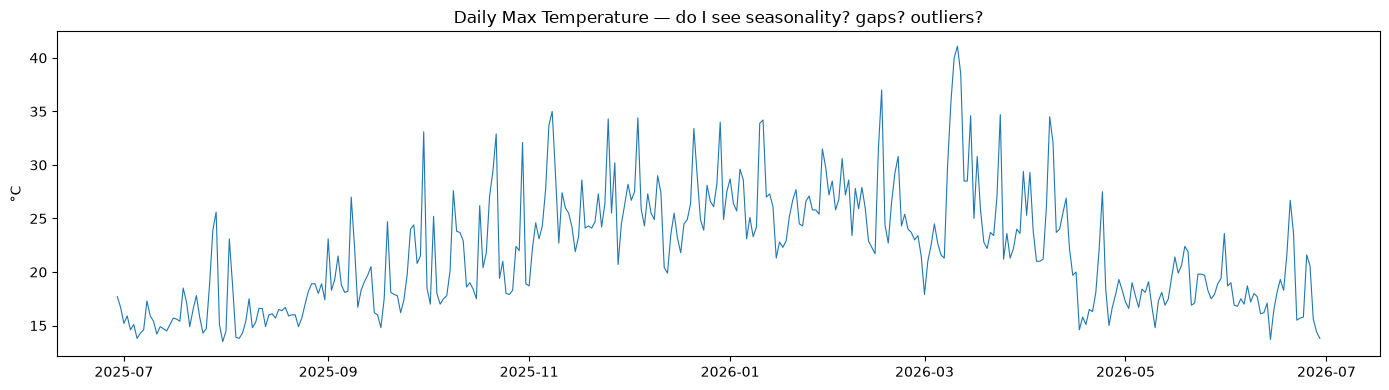

In [13]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
print(df.describe())

# Plot the target variable — what are we predicting?
plt.figure(figsize=(14, 4))
plt.plot(df["time"], df["temperature_2m_max"], linewidth=0.8)
plt.title("Daily Max Temperature — do I see seasonality? gaps? outliers?")
plt.ylabel("°C")
plt.tight_layout()
plt.show()